link al repositorio: https://github.com/paulabaal12/LAB8-RL.git

# Task 1  — Task 1.1

In [ ]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": .3})
rng = np.random.default_rng(0)

def beta_star(v):
    return np.maximum(0.0, 2.5 * (v - 12.0))      # grados

def reward(beta, v, width=8.0):
    return np.exp(-((beta - beta_star(v)) / width) ** 2)

BETA_MIN, BETA_MAX = 0.0, 30.0

---
# 1.1 (a)

DQN aproxima $Q_\theta(s,a)$ y depende del operador $\max$/$\arg\max$ en **dos** lugares:

1. **Selección de acción (política):** $\;\pi(s) = \arg\max_{a\in\mathcal{A}} Q_\theta(s,a)$
2. **Objetivo de Bellman (entrenamiento):** $\;y = r + \gamma \max_{a'\in\mathcal{A}} Q_{\theta^-}(s',a')$

(Double DQN cambia *quién* elige $a'$ pero sigue necesitando un $\arg\max$; Dueling cambia la arquitectura de la red; Prioritized Replay cambia el muestreo. Ninguna de estas variantes elimina el $\arg\max$.)

En un espacio **discreto y pequeño**, ese $\arg\max$ es trivial: la red produce un vector de $|\mathcal{A}|$ salidas y se toma el máximo en $O(|\mathcal{A}|)$. Con $\mathcal{A} = [a_{\min},a_{\max}]^d$ **continuo**:

- $\arg\max_a Q_\theta(s,a)$ es un **problema de optimización continuo en cada paso**, sobre una función $Q_\theta$ parametrizada por una red neuronal, que en general es **no convexa** en $a$. No tiene solución cerrada, y los métodos iterativos (ascenso por gradiente, CEM, muestreo) solo garantizan óptimos locales.
- Esa optimización debe resolverse **(i)** en cada paso de control en tiempo real y **(ii)** para **cada muestra del minibatch** al calcular el objetivo $y$. El costo de entrenamiento se multiplica por (tamaño de batch) × (iteraciones del optimizador interno).

### Consecuencias computacionales de aplicar DQN "directamente"

#### Opción 1 .

$$|\mathcal{A}_{\text{disc}}| = K^{d} \qquad \text{(maldición de la dimensionalidad)}$$

Además hay dos costos que no aparecen en la cuenta anterior:
- **Error de discretización (resolución):** el controlador nunca puede elegir un ángulo entre dos nodos de la malla, así que existe una pérdida irreducible de potencia $\propto \Delta^2$ con $\Delta = (a_{\max}-a_{\min})/K$ (para $r$ suave con máximo interior). Reducir $\Delta$ incrementa $K$ y por tanto el costo.
- **Se pierde la estructura:** DQN trata las $K^d$ acciones como categorías independientes, aunque $Q(s,a)$ y $Q(s,a+\epsilon)$ son casi iguales físicamente. Esto empeora la eficiencia de datos: cada acción de la malla necesita sus propios datos.
- **Control brusco (*chattering*):** con malla gruesa el controlador salta entre nodos, lo que acelera el desgaste mecánico del actuador de pitch.

#### Opción 2

### La solución estructural (lo que motiva la siguiente pregunta)

Los métodos **actor-crítico** reemplazan el $\arg\max$ por una **política paramétrica** $\mu_\phi(s)$ entrenada para maximizar $Q$ mediante el gradiente de política determinista (Silver et al., 2014):

$$\nabla_\phi J \approx \mathbb{E}_{s}\Big[\nabla_a Q_\theta(s,a)\big|_{a=\mu_\phi(s)}\;\nabla_\phi\mu_\phi(s)\Big]$$

Así el "$\arg\max$" se amortiza en una sola pasada hacia adelante de la red actor: costo $O(1)$ por paso, independiente de $d$ y de la resolución.

In [ ]:
# --- Demostración 1: explosión del número de acciones K^d ---
Ks, ds = [10, 50, 100], [1, 2, 3, 5]
print(f"{'K \\ d':>6}" + "".join(f"{d:>16}" for d in ds))
for K in Ks:
    print(f"{K:>6}" + "".join(f"{K**d:>16,}" for d in ds))
print("\nCon d=5 (3 palas individuales + yaw + torque) y K=50: ", f"{50**5:,}", "salidas en la última capa de la red.")

 K \ d               1               2               3               5
    10              10             100           1,000         100,000
    50              50           2,500         125,000     312,500,000
   100             100          10,000       1,000,000  10,000,000,000

Con d=5 (3 palas individuales + yaw + torque) y K=50:  312,500,000 salidas en la última capa de la red.


In [ ]:
# --- Demostración 2: costo de un argmax por fuerza bruta en una malla (un solo estado) ---
def Q_toy(A):                       # A: (n_actions, d)
    return np.exp(-((A - 0.3) ** 2).sum(axis=1) * 5.0)

K = 30
print(f"{'d':>3} {'#acciones':>12} {'tiempo argmax (ms)':>20}")
t_prev = None
for d in [1, 2, 3, 4]:
    grid = np.stack(np.meshgrid(*[np.linspace(0, 1, K)] * d, indexing="ij"), -1).reshape(-1, d)
    t0 = time.perf_counter(); _ = grid[np.argmax(Q_toy(grid))]; t = (time.perf_counter() - t0) * 1e3
    print(f"{d:>3} {len(grid):>12,} {t:>20.2f}")
    t_prev = t
print(f"\nExtrapolación a d=5: ~{K**5:,} acciones => ~{t_prev*K:,.0f} ms POR ESTADO (y por cada muestra del batch en el target).")

  d    #acciones   tiempo argmax (ms)
  1           30                 0.46
  2          900                 0.09
  3       27,000                 0.94
  4      810,000                40.95

Extrapolación a d=5: ~24,300,000 acciones => ~1,229 ms POR ESTADO (y por cada muestra del batch en el target).


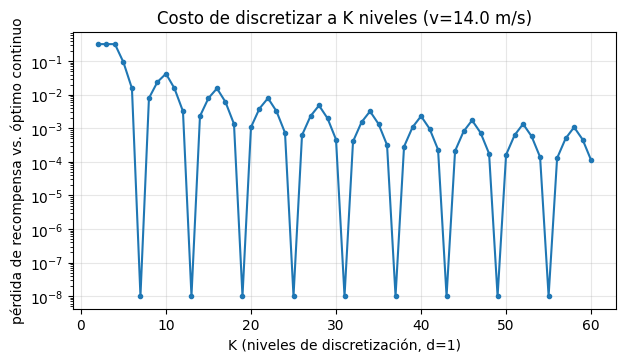

Con K=5 se pierde 9.3% de la recompensa; hacen falta K grande => K^d salidas en d>1.


In [ ]:
# --- Demostración 3: pérdida por discretización (d=1) ---
v = 14.0                                   # viento de prueba -> beta*(14)=5 grados
Ks = np.arange(2, 61)
best = []
for K in Ks:
    grid = np.linspace(BETA_MIN, BETA_MAX, K)
    best.append(reward(grid, v).max())
regret = 1.0 - np.array(best)              # el máximo continuo es 1.0

fig, ax = plt.subplots()
ax.semilogy(Ks, np.maximum(regret, 1e-8), "o-", ms=3)
ax.set_xlabel("K (niveles de discretización, d=1)"); ax.set_ylabel("pérdida de recompensa vs. óptimo continuo")
ax.set_title(f"Costo de discretizar a K niveles (v={v} m/s)")
plt.show()
print("Con K=5 se pierde", f"{regret[3]*100:.1f}%", "de la recompensa; hacen falta K grande => K^d salidas en d>1.")

---
# 1.1 (b) TD3 vs. SAC para el sistema de control en producción

Ambos son actor-crítico **off-policy** con críticos dobles (clipped double-Q) para frenar la sobreestimación, y ambos resuelven el problema del $\arg\max$ continuo. Se diferencian en la política y en cómo exploran:

| | **TD3** (Fujimoto et al., 2018) | **SAC** (Haarnoja et al., 2018) |
|---|---|---|
| Política | Determinista $\mu_\phi(s)$ | Estocástica $\pi_\phi(a\mid s)$ (gaussiana + tanh) |
| Objetivo | $\mathbb{E}\sum\gamma^t r_t$ | $\mathbb{E}\sum\gamma^t\,[\,r_t + \alpha\,\mathcal{H}(\pi(\cdot\mid s_t))\,]$ (máxima entropía) |
| Exploración | Ruido externo agregado a la acción (hiperparámetro $\sigma$) | Intrínseca, vía entropía; $\alpha$ puede ajustarse automáticamente |
| Regularización | *Target policy smoothing* + actualización retrasada del actor | Entropía como regularizador |

## Argumentos a favor de TD3

1. **Naturaleza física del sistema.** En un sistema de control industrial se valora una ley de control **determinista, reproducible y auditable**: mismo estado → misma acción. Una política estocástica desplegada implica *jitter* en el actuador de pitch (desgaste, fatiga mecánica) y complica certificación y análisis de fallos.
2. **Costo de la estocasticidad.** Si $r$ es localmente cóncava alrededor del óptimo, ejecutar $a\sim\mathcal{N}(\mu,\sigma^2)$ cuesta en promedio $\approx \tfrac12|r''|\sigma^2$ de recompensa (se verifica numéricamente abajo).
3. **Menos "piezas móviles" conceptuales:** el objetivo de TD3 es el retorno puro; no hay que decidir cuánta entropía vale en unidades de MW.

## Argumentos a favor de SAC

1. **Eficiencia de datos y estabilidad de entrenamiento.** SAC suele ser competitivo o superior a TD3 en muestras y mucho **menos sensible a hiperparámetros**: la exploración se auto-regula con $\alpha$ automático, mientras que TD3 exige afinar a mano el ruido de exploración. En simulación de dinámica de fluidos/aeroelástica, cada episodio es caro, así que esto importa.
2. **Robustez ante perturbaciones no vistas.** La máxima entropía mantiene a la política "ancha" mientras el crítico lo permita, de modo que aprende **varias** maneras razonables de actuar y no colapsa tempranamente a un máximo local estrecho del paisaje de $Q$. Eso suele traducirse en mejor comportamiento ante rachas de viento fuera de la distribución de entrenamiento. (TD3 obtiene una forma de suavidad con *target policy smoothing*, pero suaviza $Q$ respecto a la *acción*, no respecto a perturbaciones de *estado/dinámica* como el viento.)
3. **Despliegue determinista posible.** La estocasticidad de SAC es una herramienta de **entrenamiento**; en producción se puede desplegar la media $a=\tanh(\mu_\phi(s))$ y eliminar el jitter, que es justo la objeción de TD3.

## Posición

**Recomendamos SAC entrenado en simulación y desplegado en modo determinista (acción = media de la política)**, con TD3 como línea base obligatoria.

Razones: la objeción física a la política estocástica *desaparece* al desplegar la media; mientras que las ventajas de SAC (menor sensibilidad a hiperparámetros, exploración automática y política menos propensa a colapsar) se aprovechan durante el entrenamiento, que es donde son decisivas.


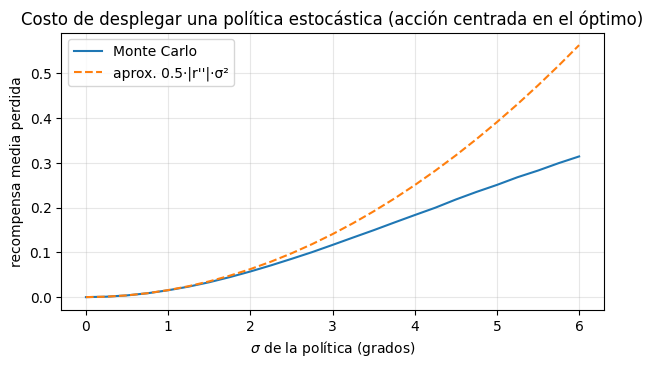

Con sigma=3 deg se pierde ~11.7% de recompensa, además de movimiento constante del actuador.
=> en producción se despliega la MEDIA de SAC (sigma=0): se conserva la calidad de entrenamiento sin el costo.


In [ ]:
# --- Demostración 4: costo de desplegar una política estocástica (jitter) vs. determinista ---
v = 15.0; bstar = beta_star(v)
sigmas = np.linspace(0, 6, 25)                       # desviación estándar de la acción, en grados
N = 200_000
loss_mc = [1 - reward(bstar + s * rng.standard_normal(N), v).mean() for s in sigmas]
loss_approx = sigmas**2 / 8.0**2                      # 0.5*|r''|*sigma^2 con r''=-2/w^2

fig, ax = plt.subplots()
ax.plot(sigmas, loss_mc, label="Monte Carlo")
ax.plot(sigmas, loss_approx, "--", label="aprox. 0.5·|r''|·σ²")
ax.set_xlabel(r"$\sigma$ de la política (grados)"); ax.set_ylabel("recompensa media perdida")
ax.legend(); ax.set_title("Costo de desplegar una política estocástica (acción centrada en el óptimo)")
plt.show()
print(f"Con sigma=3 deg se pierde ~{loss_mc[12]*100:.1f}% de recompensa, además de movimiento constante del actuador.")
print("=> en producción se despliega la MEDIA de SAC (sigma=0): se conserva la calidad de entrenamiento sin el costo.")

---
# 1.1 (c)

**CQL** (Kumar et al., 2020) aprende un crítico **conservador** que lo lleva a *subestimar* el valor de acciones fuera del soporte de los datos, añadiendo al error de Bellman la penalización
$$\alpha\Big(\mathbb{E}_{s\sim\mathcal{D}}\big[\log\textstyle\sum_{a}\exp Q(s,a)\big]-\mathbb{E}_{(s,a)\sim\mathcal{D}}\big[Q(s,a)\big]\Big)$$
que baja $Q$ en acciones "no respaldadas" por el dataset y sube $Q$ en las que sí aparecen.

## Qué política de comportamiento $\beta$ generó los datos

Los datos son una **mezcla de políticas de operadores humanos** con distintos niveles de experiencia: $\beta(a\mid s)=\sum_k w_k\,\beta_k(a\mid s)$. Es de esperar que:

- **No sea óptima ni cercana a la óptima en promedio.** Los novatos introducen sesgos y varianza altos; los expertos son mejores pero optimizan criterios implícitos (seguridad, desgaste, reglas del fabricante) que no coinciden exactamente con la recompensa que definimos.
- **Sea multimodal y heterogénea.** Distintos operadores reaccionan distinto al mismo estado.
- **Sea típicamente conservadora** en condiciones extremas (feathering/paro ante vientos fuertes) y casi determinista para cada operador: poca variación de acción *dado* el estado.
- **Esté parcialmente confundida:** los operadores deciden con información que no está en $s$ (pronósticos, experiencia con ese sitio), de modo que $\beta(a\mid s)$ no es una "política" que se pueda replicar solo con las observaciones.


## Qué cobertura del espacio estado-acción esperar

- **Estados:** buena cobertura de la operación **habitual** (vientos moderados, 3 años ≈ 3 ciclos estacionales completos) y **cobertura pobre de eventos raros**: ráfagas extremas, cizalladura fuerte, remanentes de tormentas tropicales, fallas parciales.
- **Acciones:** un operador competente actúa dentro de una banda estrecha alrededor de lo "conocido como seguro". Es decir, para un estado dado, **la cobertura de acciones es angosta**: la región donde un agente de RL podría encontrar mejoras (acciones que ningún humano probó) está, casi por definición, fuera de soporte.
- **Desajuste de dinámica:** son turbinas *"similares"*, no las mismas; terreno, turbulencia y densidad del aire en el altiplano generan un pequeño *shift* de dinámica adicional.

## Las dos condiciones de Offline RL

Interpretamos las dos condiciones como: **(C1) Cobertura**: el dataset debe cubrir los pares $(s,a)$ que la política objetivo visitaría (concentrabilidad $C^\pi<\infty$); y **(C2) Calidad**: la política de comportamiento debe ser razonablemente buena, o al menos el dataset debe contener suficiente comportamiento de alto retorno.

**La más difícil de satisfacer aquí es C1 (cobertura).** porque:

1. C2 se **mitiga** por la propia estructura del dataset: la mezcla incluye operadores expertos, y CQL tolera datos subóptimos mientras haya soporte.
2. C1 **no se puede arreglar con algoritmo**: ningún método offline puede aprender de manera confiable sobre pares $(s,a)$ sobre los que no hay datos. Y el dominio la empeora dos veces: la acción es *continua* (el volumen de acciones posibles es infinito, el humano visita una banda mínima) y las situaciones donde más importa el control (vientos extremos) son justo las menos observadas, porque los humanos las evitan por seguridad.
3. Consecuencia: la mejora que CQL puede lograr está **acotada por el soporte**; es un problema de datos, no de algoritmo.

el dataset es **apropiado para CQL como mejora conservadora sobre los operadores**, pero no como base para un control que opere agresivamente fuera de lo que los humanos hicieron.

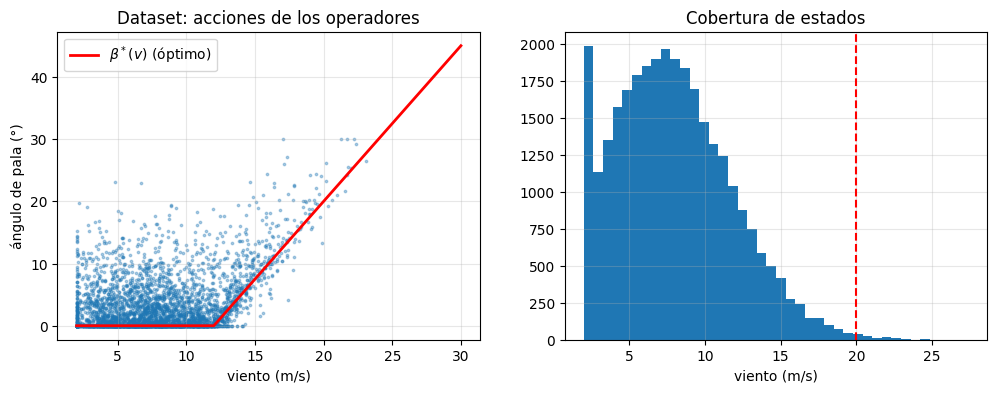

Muestras con viento > 20 m/s: 0.35%  (n=104)
   experto:  97.5% de sus acciones están a <2° del óptimo
intermedio:  55.1% de sus acciones están a <2° del óptimo
    novato:  35.6% de sus acciones están a <2° del óptimo

Global: 61.9% cerca del óptimo -> beta no es óptima, pero tampoco inútil (mezcla).
Los pares (s,a) de viento extremo son escasos y los operadores allí se limitan a un rango estrecho => C1 (cobertura) es el cuello de botella.


In [ ]:
# --- Demostración 5: cobertura de un dataset sintético generado por operadores de distinta experiencia ---
# SUPUESTO: cada operador actúa como beta*(v) + sesgo + ruido. El experto es casi determinista; el novato es ruidoso y conservador.
ops = {"experto":    dict(bias=0.0, sigma=1.0, w=0.3),
       "intermedio": dict(bias=1.5, sigma=3.0, w=0.4),
       "novato":     dict(bias=4.0, sigma=6.0, w=0.3)}
N = 30_000
# viento tipo Weibull (muchos días moderados, pocas ráfagas fuertes)
v = np.clip(rng.weibull(2.2, N) * 9.0, 2, 30)
who = rng.choice(list(ops), size=N, p=[o["w"] for o in ops.values()])
beta = np.array([np.clip(beta_star(vi) + ops[w]["bias"] + ops[w]["sigma"] * rng.standard_normal(), BETA_MIN, BETA_MAX)
                 for vi, w in zip(v, who)])

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sel = rng.choice(N, 4000, replace=False)
axs[0].scatter(v[sel], beta[sel], s=3, alpha=.35)
vv = np.linspace(2, 30, 200)
axs[0].plot(vv, beta_star(vv), "r", lw=2, label=r"$\beta^*(v)$ (óptimo)"); axs[0].set_xlabel("viento (m/s)"); axs[0].set_ylabel("ángulo de pala (°)")
axs[0].legend(); axs[0].set_title("Dataset: acciones de los operadores")
h = axs[1].hist(v, bins=40); axs[1].axvline(20, color="r", ls="--"); axs[1].set_xlabel("viento (m/s)"); axs[1].set_title("Cobertura de estados")
plt.show()

print(f"Muestras con viento > 20 m/s: {(v>20).mean()*100:.2f}%  (n={(v>20).sum()})")
for k in ops:
    m = who == k
    near = (np.abs(beta[m] - beta_star(v[m])) < 2.0).mean() * 100
    print(f"{k:>10}: {near:5.1f}% de sus acciones están a <2° del óptimo")
print(f"\nGlobal: {(np.abs(beta - beta_star(v))<2).mean()*100:.1f}% cerca del óptimo -> beta no es óptima, pero tampoco inútil (mezcla).")
print("Los pares (s,a) de viento extremo son escasos y los operadores allí se limitan a un rango estrecho => C1 (cobertura) es el cuello de botella.")

---
# 1.1 (d)

## El problema: error de extrapolación

En Q-Learning/actor-crítico off-policy, el objetivo de Bellman evalúa el crítico en la acción que elegiría la **política actual**:
$$y = r + \gamma\, Q_{\theta^-}\big(s',\,a'\big),\qquad a' = \arg\max_a Q(s',a)\ \ \text{(o } \mu_\phi(s')\text{)}$$

Cuando se entrena **solo con un dataset fijo**, el crítico ha sido ajustado únicamente en pares $(s,a)\sim\mathcal{D}$. Para $a'$ **fuera del soporte** de $\mathcal{D}$, $Q_\theta(s',a')$ es una **extrapolación arbitraria** del aproximador de funciones, sin ningún dato que la corrija. Esto se agrava por tres mecanismos que se refuerzan:

1. **El $\max$ es un seleccionador de errores positivos:** entre todas las acciones, elige precisamente aquella donde la red *sobrestima* el valor (maldición del ganador). Es el mismo sesgo de sobrestimación de DQN, pero aquí sin válvula de escape.
2. **El *bootstrapping* propaga y amplifica el error:** el valor inflado de $(s',a')$ entra en el objetivo de $(s,a)$ y se propaga hacia atrás en el tiempo, acumulándose a lo largo del horizonte ($\sim 1/(1-\gamma)$).
3. **No hay retroalimentación del entorno:** en online RL, ejecutar la acción "ilusoria" revelaría que su valor real es bajo y el crítico se corregiría. En offline RL **nunca se ejecuta**, así que el error **nunca se corrige** (Fujimoto et al., 2019; Levine et al., 2020).

Resultado típico: $Q$ diverge o se vuelve optimista, y la política converge hacia acciones fuera de distribución donde el crítico está equivocado.


In [ ]:
# --- Demostración 6: error de extrapolación (Q-learning estándar) vs. CQL con log-sum-exp ---
from scipy.optimize import minimize
V = 18.0                                       # beta*(18) = 15 grados
def true_reward(b):
    base = reward(b, V)
    overspeed = 3.0 * np.maximum(0.0, (8.0 - b) / 8.0) ** 2     # castigo por ángulo bajo con viento fuerte
    return base - overspeed

DEG = 8
grid = np.linspace(BETA_MIN, BETA_MAX, 301)
def feats(b):                                   # crítico flexible: polinomios de Legendre en variable normalizada
    return np.polynomial.legendre.legvander((np.asarray(b) - 15.0) / 15.0, DEG)
Phi_grid = feats(grid)

def fit(b_data, y, alpha=0.0, lam=1e-4):
    # minimiza  MSE(Q(a_data), y) + alpha*( logsumexp_a Q(a) - E_data[Q(a)] ) + lam*|w|^2   (alpha=0 -> Q-learning estándar)
    P = feats(b_data); n = len(b_data); md = P.mean(0)
    def f(w):
        z = Phi_grid @ w; m = z.max(); sm = np.exp(z - m); lse = m + np.log(sm.mean()); sm /= sm.sum()
        L = np.mean((P @ w - y) ** 2) + alpha * (lse - md @ w) + lam * w @ w
        g = 2 / n * P.T @ (P @ w - y) + alpha * (Phi_grid.T @ sm - md) + 2 * lam * w
        return L, g
    return minimize(f, np.zeros(DEG + 1), jac=True, method="L-BFGS-B", options=dict(maxiter=2000)).x

def make_data(seed):
    r = np.random.default_rng(seed)
    b = np.clip(r.normal(11.0, 1.5, 80), 7, 15)                 # acciones de operadores (soporte ~[7,15])
    return b, true_reward(b) + 0.1 * r.standard_normal(len(b))

def run(seed, alpha):
    b, y = make_data(seed)
    w = fit(b, y, alpha); q = Phi_grid @ w; a_star = grid[np.argmax(q)]
    return a_star, q.max(), true_reward(a_star), (b.min(), b.max()), w

for name, alpha in [("Q-learning estándar", 0.0), ("CQL (alpha=1.0)", 1.0)]:
    out = [run(s, alpha) for s in range(150)]
    qh = np.array([o[1] for o in out]); rt = np.array([o[2] for o in out])
    ood = np.array([(o[0] < o[3][0] - 1) or (o[0] > o[3][1] + 1) for o in out])
    print(f"{name:>22}: acción fuera de soporte en {ood.mean()*100:5.1f}% de 150 semillas | "
          f"recompensa REAL media = {rt.mean():5.2f} | peor caso = {rt.min():6.2f}")
print(f"\nReferencia: óptimo real ~ {true_reward(grid).max():.2f}. Las acciones fuera de soporte pueden caer en la zona de sobrevelocidad (recompensa negativa).")

   Q-learning estándar: acción fuera de soporte en  48.7% de 150 semillas | recompensa REAL media =  0.65 | peor caso =  -2.97
       CQL (alpha=1.0): acción fuera de soporte en   0.0% de 150 semillas | recompensa REAL media =  0.83 | peor caso =   0.76

Referencia: óptimo real ~ 1.00. Las acciones fuera de soporte pueden caer en la zona de sobrevelocidad (recompensa negativa).


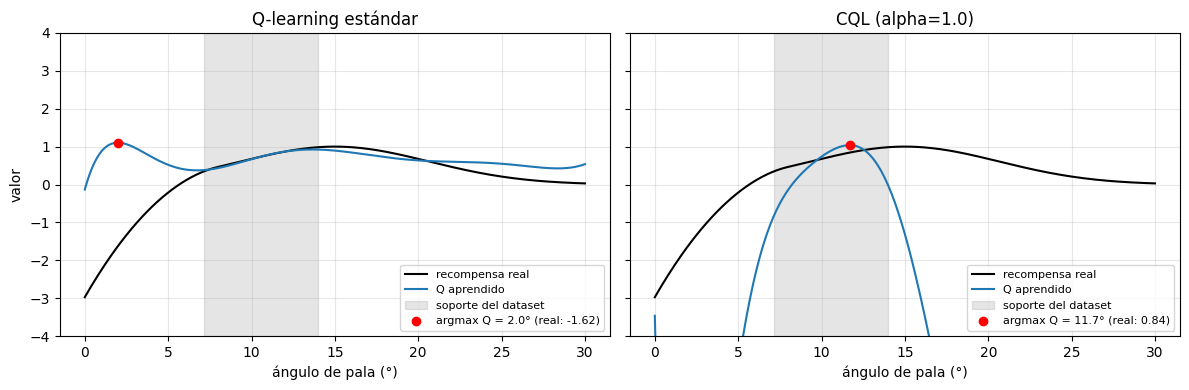

In [ ]:
# Visualización de un caso donde el Q-learning estándar extrapola mal
seed = next(s for s in range(150) if true_reward(run(s, 0.0)[0]) < 0.3)
b, _ = make_data(seed)
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, alpha) in zip(axs, [("Q-learning estándar", 0.0), ("CQL (alpha=1.0)", 1.0)]):
    a_star, qmax, rt, _, w = run(seed, alpha)
    ax.plot(grid, true_reward(grid), "k", label="recompensa real")
    ax.plot(grid, Phi_grid @ w, "C0", label="Q aprendido")
    ax.axvspan(b.min(), b.max(), color="gray", alpha=.2, label="soporte del dataset")
    ax.scatter([a_star], [qmax], c="r", zorder=5, label=f"argmax Q = {a_star:.1f}° (real: {rt:.2f})")
    ax.set_ylim(-4, 4); ax.set_xlabel("ángulo de pala (°)"); ax.set_title(name); ax.legend(loc="lower right", fontsize=8)
axs[0].set_ylabel("valor")
plt.tight_layout(); plt.show()

el crítico extrapola fuera del soporte (zona gris), el $\arg\max$ **cae en los extremos** donde $Q$ está inflado y la acción elegida es mala *en la realidad* (la recompensa real incluye la penalización por sobrevelocidad que el dataset nunca mostró). Con la penalización conservadora (CQL), $Q$ queda "anclado" a los datos: el $\arg\max$ permanece dentro o cerca del soporte y la recompensa real es mucho mejor. Este es el mecanismo exacto por el cual CQL (y BCQ, IQL, TD3+BC, etc.) hace viable el offline RL.

---
# 1.2 (a) Escriban el objetivo de optimización de SAC incluyendo el término de entropía. Identifiquen cada variable con su significado en el contexto del sistema de turbinas: ¿qué representa 𝛼, qué representaℋ(𝜋(⋅∣ 𝑆𝑡)), y cómo se calibraría 𝛼 automáticamente durante el entrenamiento?

En este caso SAC no solo maximiza la recompensa, ya que también premia que la política siga siendo aleatoria. En donde su objetivo es:

$$J(\pi)=\mathbb{E}_{\pi}\Big[\sum_{t}\gamma^{t}\big(r_t+\alpha\,\mathcal{H}(\pi(\cdot\mid s_t))\big)\Big]$$

Qué significa cada cosa en el sistema de turbinas:

1. $r_t$ es la energía generada en el paso $t$.
2. $\mathcal{H}(\pi(\cdot\mid s_t))=-\mathbb{E}_{a\sim\pi}[\log\pi(a\mid s_t)]$ mide qué tan dispersa es la política ante un viento dado. Con entropía alta la turbina probaría ángulos de pala muy distintos, con entropía baja casi siempre elegiría el mismo.
3. $\alpha$ es la temperatura. Decide cuánto vale explorar frente a generar energía. Si es grande la turbina experimenta mucho, si es pequeña se vuelve casi determinista.

Por lo cuál para calibrar $\alpha$ automáticamente se fija una entropía objetivo $\bar{\mathcal{H}}=-\dim(\mathcal{A})$ y se minimiza

$$J(\alpha)=\mathbb{E}_{a\sim\pi}\big[-\alpha\,(\log\pi(a\mid s)+\bar{\mathcal{H}})\big]$$

En este csao si la entropía real cae por debajo del objetivo, $\alpha$ sube y empuja a explorar más. Si queda por encima, $\alpha$ baja y la política se concentra en lo que ya funciona. En la práctica se aprende $\log\alpha$ con descenso por gradiente.

---
# 1.2 (b) Comparen el target de actualización del Critic en TD3 versus SAC. ¿Cuál de los dos produce estimaciones más conservadoras del valor y por qué? ¿Esa conservatividad es una ventaja o una desventaja para el dominio de turbinas?

**TD3:**

$$y=r+\gamma\min_{i=1,2}Q_{\theta_i'}(s',\tilde a),\qquad \tilde a=\text{clip}\big(\mu_{\phi'}(s')+\text{clip}(\epsilon,-c,c),\,a_{low},a_{high}\big)$$

**SAC:**

$$y=r+\gamma\Big(\min_{i=1,2}Q_{\theta_i'}(s',a')-\alpha\log\pi(a'\mid s')\Big),\qquad a'\sim\pi(\cdot\mid s')$$

En este caso los dos usan el mínimo de dos críticos para frenar la sobreestimación. La diferencia es que SAC le suma el bono de entropía $-\alpha\log\pi$, que infla un poco el target, mientras que TD3 le mete ruido a la acción objetivo para que $Q$ no se aproveche de picos estrechos. Por eso TD3 da estimaciones más conservadoras. Hay que tener en cuenta que los valores no son del todo comparables, porque SAC optimiza un objetivo distinto recompensa más entropía.

Para las turbinas la conservatividad es sobre todo una ventaja, ya que preferimos un crítico que no sea optimista con ángulos raros que podrían dañar el equipo. La desventaja es que puede subestimar acciones buenas y aprender más lento. Además, no reemplaza una restricción real contra acciones fuera de los datos, que es justo lo que hace CQL.

---
# 1.2 (c) Escriban el objetivo de CQL identificando los dos términos que se añaden a la pérdida TD estándar. Expliquen en palabras qué hace cada término y por qué su combinación produce un Critic conservador. Luego argumenten qué valor de 𝛼𝐶𝑄𝐿 recomendarían para el dataset de turbinas considerando la heterogeneidad de los operadores que lo generaron.

$$\min_Q\;\; \alpha_{CQL}\Big(\mathbb{E}_{s\sim\mathcal{D}}\big[\log\textstyle\sum_{a}\exp Q(s,a)\big]-\mathbb{E}_{(s,a)\sim\mathcal{D}}\big[Q(s,a)\big]\Big)+\tfrac{1}{2}\,\mathbb{E}\big[(Q(s,a)-\mathcal{B}\hat Q(s,a))^2\big]$$

El último término es la pérdida TD . Los dos que se añaden son:

1. **$\log\sum_a\exp Q(s,a)$**: es un máximo suave sobre todas las acciones. Minimizarlo baja el valor de las acciones con $Q$ alto, justo las que el crítico podría estar sobreestimando.
2. **$-\mathbb{E}_{\mathcal{D}}[Q(s,a)]$**: sube el valor de las acciones que sí aparecen en el dataset.

En este caso combinados, bajan el valor de lo que nunca se vio y lo mantienen donde hay evidencia real. El resultado es un crítico pesimista fuera de los datos, así que el $\arg\max$ no se escapa hacia acciones inventadas.

**Valor recomendado de $\alpha_{CQL}$:** alrededor de **1.0**. Debido a que los operadores son una mezcla de novatos y expertos, o sea que el dataset es heterogéneo y de calidad media. Si $\alpha$ es muy bajo (0.5 o menos), vuelve el error de extrapolación. Si es muy alto (5.0), el crítico queda tan pegado a los datos que la política termina copiando al operador promedio, que no es óptimo. Un valor intermedio deja algo de espacio para mejorar sin irse a zonas sin datos. Lo confirmaremos con el experimento de la Task 2.2.

---
# Task 2 (Entrega Final) — Task 2.1

En esta parte implementamos TD3 y SAC desde cero con PyTorch y los probamos en Pendulum-v1, que usamos como un "mini simulador" del control de la turbina. Tiene una sola acción continua (el torque, entre −2 y 2) y un estado de tres números, así que es lo bastante simple para correr rápido pero conserva lo importante: acciones continuas y una recompensa que castiga alejarse del objetivo.

Ambos algoritmos comparten la misma base: buffer de 100,000 transiciones, minibatch de 256, redes target con $\tau = 0.005$, dos capas ocultas de 256 neuronas con ReLU y 100,000 pasos de entrenamiento. Primero definimos todas esas piezas comunes y después cada algoritmo por separado.

Cada 1,000 pasos registramos tres cosas: la recompensa promedio de 10 episodios jugando sin exploración (greedy), el valor Q promedio sobre un conjunto fijo de 1,000 estados y, solo para SAC, la entropía de la política. Para el valor Q usamos $Q_1(s, \pi(s))$, es decir, cuánto cree el crítico que vale la acción que la política elegiría en esos estados fijos. Así la medida es comparable entre los dos algoritmos y a lo largo del tiempo.


In [ ]:
import os, json, time, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

ENV_ID = "Pendulum-v1"
OBS_DIM, ACT_DIM, MAX_ACTION = 3, 1, 2.0

BUFFER_SIZE = 100_000
BATCH_SIZE  = 256
TAU         = 0.005
HIDDEN      = 256
TOTAL_STEPS = 100_000
EVAL_EVERY  = 1_000
EVAL_EPISODES = 10

GAMMA       = 0.99
LR          = 3e-4
START_STEPS = 5_000     

RESULTS_DIR = "resultados_task2"
os.makedirs(RESULTS_DIR, exist_ok=True)
RERUN = False # True = volver a entrenar aunque ya existan resultados guardados

COLORS = {"TD3": "#2a78d6", "SAC": "#eb6834", "CQL": "#1baf7a", "ref": "#52514e"}
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2})

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

def save_json(name, obj):
    with open(os.path.join(RESULTS_DIR, name), "w") as f:
        json.dump(obj, f)

def load_json(name):
    path = os.path.join(RESULTS_DIR, name)
    if os.path.exists(path) and not RERUN:
        with open(path) as f:
            return json.load(f)
    return None

Dispositivo: cuda


### Piezas comunes: redes, buffer, evaluación y conjunto fijo de estados

Aquí van los bloques que usan los dos algoritmos (y que luego reutiliza CQL en la Task 2.2). El crítico siempre es doble (*twin critics*): dos redes Q independientes, porque tanto TD3 como SAC toman el mínimo de ambas para no sobreestimar.

El conjunto fijo de 1,000 estados lo generamos una sola vez con acciones aleatorias, reiniciando el péndulo cada 50 pasos para que haya estados de todo tipo (abajo, arriba, girando rápido, etc.).

In [ ]:
def mlp(in_dim, out_dim):
    return nn.Sequential(nn.Linear(in_dim, HIDDEN), nn.ReLU(),
                         nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
                         nn.Linear(HIDDEN, out_dim))

def soft_update(net, target, tau=TAU):
    with torch.no_grad():
        for p, tp in zip(net.parameters(), target.parameters()):
            tp.mul_(1 - tau).add_(tau * p)

class ReplayBuffer:
    def __init__(self, capacity=BUFFER_SIZE):
        self.cap, self.ptr, self.size = capacity, 0, 0
        self.s  = np.zeros((capacity, OBS_DIM), np.float32)
        self.a  = np.zeros((capacity, ACT_DIM), np.float32)
        self.r  = np.zeros((capacity, 1), np.float32)
        self.s2 = np.zeros((capacity, OBS_DIM), np.float32)
        self.d  = np.zeros((capacity, 1), np.float32)

    def add(self, s, a, r, s2, d):
        i = self.ptr
        self.s[i], self.a[i], self.r[i], self.s2[i], self.d[i] = s, a, r, s2, d
        self.ptr = (i + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, n=BATCH_SIZE):
        idx = np.random.randint(0, self.size, n)
        t = lambda x: torch.as_tensor(x[idx], device=DEVICE)
        return t(self.s), t(self.a), t(self.r), t(self.s2), t(self.d)

class TwinCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.q1 = mlp(OBS_DIM + ACT_DIM, 1)
        self.q2 = mlp(OBS_DIM + ACT_DIM, 1)

    def forward(self, s, a):
        sa = torch.cat([s, a], dim=-1)
        return self.q1(sa), self.q2(sa)

def evaluate(policy_fn, episodes=EVAL_EPISODES, seed=10_000):
    env = gym.make(ENV_ID)
    returns = []
    for ep in range(episodes):
        s, _ = env.reset(seed=seed + ep)
        done, R = False, 0.0
        while not done:
            s, r, term, trunc, _ = env.step(policy_fn(s))
            R += r
            done = term or trunc
        returns.append(R)
    env.close()
    return float(np.mean(returns))

def make_fixed_states(n=1_000, seed=123, reset_every=50):
    env = gym.make(ENV_ID)
    rng = np.random.default_rng(seed)
    states = []
    s, _ = env.reset(seed=seed)
    for i in range(n):
        states.append(s)
        a = rng.uniform(-MAX_ACTION, MAX_ACTION, ACT_DIM).astype(np.float32)
        s, _, term, trunc, _ = env.step(a)
        if term or trunc or (i + 1) % reset_every == 0:
            s, _ = env.reset()
    env.close()
    return torch.as_tensor(np.array(states, np.float32), device=DEVICE)

FIXED_S = make_fixed_states()
print("Conjunto fijo de estados:", tuple(FIXED_S.shape))

Conjunto fijo de estados: (1000, 3)


### TD3

TD3 usa una política determinista (una red que devuelve directamente el torque) y le suma ruido gaussiano solo para explorar mientras entrena. Sus tres trucos están marcados en el código: los dos críticos con el mínimo en el target, el *target policy smoothing* (ruido con $\sigma = 0.2$ recortado a $c = 0.5$ sobre la acción del target) y el *policy delay*, que actualiza el actor y las redes target solo cada 2 pasos del crítico.

In [ ]:
class DeterministicActor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp(OBS_DIM, ACT_DIM)

    def forward(self, s):
        return MAX_ACTION * torch.tanh(self.net(s))

class TD3:
    name = "TD3"

    def __init__(self, policy_noise=0.2, noise_clip=0.5, policy_delay=2, expl_noise=0.1):
        self.actor = DeterministicActor().to(DEVICE)
        self.actor_t = copy.deepcopy(self.actor)
        self.critic = TwinCritic().to(DEVICE)
        self.critic_t = copy.deepcopy(self.critic)
        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=LR)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=LR)
        self.policy_noise, self.noise_clip = policy_noise, noise_clip
        self.policy_delay, self.expl_noise = policy_delay, expl_noise
        self.it = 0

    @torch.no_grad()
    def act(self, s, explore=False):
        s = torch.as_tensor(s, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a = self.actor(s)[0].cpu().numpy()
        if explore:
            a = a + np.random.normal(0, self.expl_noise * MAX_ACTION, ACT_DIM)
        return np.clip(a, -MAX_ACTION, MAX_ACTION).astype(np.float32)

    def update(self, buf):
        self.it += 1
        s, a, r, s2, d = buf.sample()

        with torch.no_grad():
            noise = (torch.randn_like(a) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
            a2 = (self.actor_t(s2) + noise).clamp(-MAX_ACTION, MAX_ACTION)
            q1_t, q2_t = self.critic_t(s2, a2)
            y = r + GAMMA * (1 - d) * torch.min(q1_t, q2_t)

        q1, q2 = self.critic(s, a)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        if self.it % self.policy_delay == 0:
            actor_loss = -self.critic(s, self.actor(s))[0].mean()
            self.actor_opt.zero_grad()
            actor_loss.backward()
            self.actor_opt.step()
            soft_update(self.actor, self.actor_t)
            soft_update(self.critic, self.critic_t)

    @torch.no_grad()
    def q_estimate(self, S):
        return self.critic(S, self.actor(S))[0].mean().item()

### SAC

SAC usa una política estocástica: la red da una media y una desviación estándar, se muestrea con el truco de reparametrización ($u = \mu + \sigma \epsilon$) y se aplica `tanh` para que la acción quede dentro de $[-2, 2]$. Como `tanh` deforma la distribución, hay que corregir el logaritmo de la probabilidad (esa es la línea con `softplus`, que es la forma numéricamente estable de $\log(1 - \tanh^2 u)$).

La temperatura $\alpha$ se ajusta sola con entropía objetivo $-\dim(\mathcal{A}) = -1$. Para evaluar usamos la media de la política (sin muestrear), que es justo el "modo determinista" que propusimos para desplegar en la Task 1.1b. La entropía que registramos es $-\mathbb{E}[\log \pi(a \mid s)]$ estimada sobre el conjunto fijo de estados.

In [4]:
LOG_STD_MIN, LOG_STD_MAX = -20, 2

class GaussianActor(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(OBS_DIM, HIDDEN), nn.ReLU(),
                                  nn.Linear(HIDDEN, HIDDEN), nn.ReLU())
        self.mu = nn.Linear(HIDDEN, ACT_DIM)
        self.log_std = nn.Linear(HIDDEN, ACT_DIM)

    def forward(self, s, deterministic=False):
        h = self.body(s)
        mu = self.mu(h)
        log_std = self.log_std(h).clamp(LOG_STD_MIN, LOG_STD_MAX)
        std = log_std.exp()
        # Reparametrización: u = mu + std * eps
        u = mu if deterministic else mu + std * torch.randn_like(mu)
        a = torch.tanh(u)
        # log-prob gaussiana + corrección por tanh y por el escalado a [-2, 2]
        logp = (-0.5 * ((u - mu) / std) ** 2 - log_std - 0.5 * np.log(2 * np.pi)).sum(-1, keepdim=True)
        logp -= (2 * (np.log(2) - u - F.softplus(-2 * u)) + np.log(MAX_ACTION)).sum(-1, keepdim=True)
        return MAX_ACTION * a, logp

class SAC:
    name = "SAC"

    def __init__(self):
        self.actor = GaussianActor().to(DEVICE)
        self.critic = TwinCritic().to(DEVICE)
        self.critic_t = copy.deepcopy(self.critic)
        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=LR)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=LR)
        # alpha automático: se aprende log(alpha) con entropía objetivo -dim(A)
        self.log_alpha = torch.zeros(1, requires_grad=True, device=DEVICE)
        self.alpha_opt = torch.optim.Adam([self.log_alpha], lr=LR)
        self.target_entropy = -float(ACT_DIM)

    @property
    def alpha(self):
        return self.log_alpha.exp().item()

    @torch.no_grad()
    def act(self, s, explore=False):
        s = torch.as_tensor(s, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a, _ = self.actor(s, deterministic=not explore)
        return a[0].cpu().numpy().astype(np.float32)

    def td_target(self, r, s2, d):
        with torch.no_grad():
            a2, logp2 = self.actor(s2)
            q1_t, q2_t = self.critic_t(s2, a2)
            return r + GAMMA * (1 - d) * (torch.min(q1_t, q2_t) - self.alpha * logp2)

    def extra_critic_loss(self, s, a, s2, q1, q2):
        return 0.0          # SAC no tiene término extra (CQL lo sobrescribe)

    def update(self, buf):
        s, a, r, s2, d = buf.sample()

        # --- Crítico ---
        y = self.td_target(r, s2, d)
        q1, q2 = self.critic(s, a)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y) + self.extra_critic_loss(s, a, s2, q1, q2)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        # --- Actor ---
        a_new, logp = self.actor(s)
        q1_pi, q2_pi = self.critic(s, a_new)
        actor_loss = (self.alpha * logp - torch.min(q1_pi, q2_pi)).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        # --- Temperatura alpha ---
        alpha_loss = -(self.log_alpha * (logp.detach() + self.target_entropy)).mean()
        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()

        soft_update(self.critic, self.critic_t)

    @torch.no_grad()
    def q_estimate(self, S):
        a, _ = self.actor(S, deterministic=True)
        return self.critic(S, a)[0].mean().item()

    @torch.no_grad()
    def entropy(self, S):
        _, logp = self.actor(S)
        return -logp.mean().item()

### Ciclo de entrenamiento (compartido)

Es el mismo para los dos algoritmos: los primeros 5,000 pasos se juega al azar para llenar el buffer, después el agente actúa con su exploración y hace una actualización por cada paso de ambiente. Pendulum-v1 nunca "termina", solo se corta a los 200 pasos, por eso para el bootstrap usamos solo terminated y no truncated (si no, el agente creería que el mundo se acaba cada 200 pasos).

In [5]:
def train_online(agent, total_steps=TOTAL_STEPS, seed=0, verbose_every=10_000):
    set_seed(seed)
    env = gym.make(ENV_ID)
    env.action_space.seed(seed)
    buf = ReplayBuffer()
    s, _ = env.reset(seed=seed)
    log = {"step": [], "eval_return": [], "q_mean": [], "entropy": [], "alpha": []}
    t0 = time.time()

    for t in range(1, total_steps + 1):
        if t <= START_STEPS:
            a = env.action_space.sample()
        else:
            a = agent.act(s, explore=True)
        s2, r, term, trunc, _ = env.step(a)
        buf.add(s, a, r, s2, float(term))
        s = s2
        if term or trunc:
            s, _ = env.reset()

        if t > START_STEPS:
            agent.update(buf)

        if t % EVAL_EVERY == 0:
            log["step"].append(t)
            log["eval_return"].append(evaluate(lambda o: agent.act(o, explore=False)))
            log["q_mean"].append(agent.q_estimate(FIXED_S))
            if hasattr(agent, "entropy"):
                log["entropy"].append(agent.entropy(FIXED_S))
                log["alpha"].append(agent.alpha)
            if t % verbose_every == 0:
                extra = f" | H={log['entropy'][-1]:6.3f} alpha={log['alpha'][-1]:.4f}" if log["entropy"] else ""
                print(f"[{agent.name}] paso {t:>6} | eval {log['eval_return'][-1]:8.1f} | "
                      f"Q {log['q_mean'][-1]:8.1f}{extra} | {time.time() - t0:5.0f}s")
    env.close()
    return log

### Entrenamiento de TD3 (100,000 pasos)

In [8]:
td3_log = load_json("td3_log.json")
if td3_log is None:
    td3_agent = TD3()
    td3_log = train_online(td3_agent, seed=0)
    save_json("td3_log.json", td3_log)
else:
    print("TD3: resultados cargados de disco")
print(f"TD3 -> recompensa final (prom. últimas 10 evaluaciones): {np.mean(td3_log['eval_return'][-10:]):.1f}")

[TD3] paso  10000 | eval   -162.4 | Q    -65.0 |    37s
[TD3] paso  20000 | eval   -110.1 | Q   -121.3 |   102s
[TD3] paso  30000 | eval   -108.8 | Q   -117.8 |   166s
[TD3] paso  40000 | eval   -109.7 | Q   -116.0 |   230s
[TD3] paso  50000 | eval   -109.3 | Q   -120.8 |   294s
[TD3] paso  60000 | eval   -109.0 | Q   -123.5 |   358s
[TD3] paso  70000 | eval   -109.9 | Q   -127.0 |   422s
[TD3] paso  80000 | eval   -109.0 | Q   -127.8 |   487s
[TD3] paso  90000 | eval   -109.3 | Q   -129.0 |   551s
[TD3] paso 100000 | eval   -108.8 | Q   -129.6 |   615s
TD3 -> recompensa final (prom. últimas 10 evaluaciones): -109.2


### Entrenamiento de SAC (100,000 pasos)

In [6]:
sac_log = load_json("sac_log.json")
if sac_log is None:
    sac_agent = SAC()
    sac_log = train_online(sac_agent, seed=0)
    save_json("sac_log.json", sac_log)
else:
    print("SAC: resultados cargados de disco")
print(f"SAC -> recompensa final (prom. últimas 10 evaluaciones): {np.mean(sac_log['eval_return'][-10:]):.1f}")

[SAC] paso  10000 | eval   -122.8 | Q   -100.2 | H=-0.149 alpha=0.2742 |    78s
[SAC] paso  20000 | eval   -107.8 | Q   -112.5 | H=-2.875 alpha=0.0326 |   208s
[SAC] paso  30000 | eval   -119.1 | Q   -117.7 | H=-2.829 alpha=0.0277 |   333s
[SAC] paso  40000 | eval   -113.8 | Q   -120.2 | H=-2.970 alpha=0.0222 |   457s
[SAC] paso  50000 | eval   -108.5 | Q   -121.0 | H=-2.618 alpha=0.0258 |   582s
[SAC] paso  60000 | eval   -108.2 | Q   -122.0 | H=-3.093 alpha=0.0186 |   705s
[SAC] paso  70000 | eval   -107.9 | Q   -122.3 | H=-3.050 alpha=0.0190 |   829s
[SAC] paso  80000 | eval   -108.0 | Q   -123.0 | H=-3.409 alpha=0.0154 |   953s
[SAC] paso  90000 | eval   -108.1 | Q   -124.4 | H=-3.873 alpha=0.0139 |  1079s
[SAC] paso 100000 | eval   -108.0 | Q   -124.0 | H=-3.299 alpha=0.0136 |  1207s
SAC -> recompensa final (prom. últimas 10 evaluaciones): -109.6


In [ ]:
# Resumen de lo registrado cada 1,000 pasos
print(f"{'paso':>7} | {'TD3 eval':>9} {'TD3 Q':>8} | {'SAC eval':>9} {'SAC Q':>8} {'SAC H':>7} {'alpha':>7}")
for i in range(9, len(td3_log["step"]), 10):
    print(f"{td3_log['step'][i]:>7} | {td3_log['eval_return'][i]:9.1f} {td3_log['q_mean'][i]:8.1f} | "
          f"{sac_log['eval_return'][i]:9.1f} {sac_log['q_mean'][i]:8.1f} {sac_log['entropy'][i]:7.3f} {sac_log['alpha'][i]:7.4f}")

   paso |  TD3 eval    TD3 Q |  SAC eval    SAC Q   SAC H   alpha
  10000 |    -162.4    -65.0 |    -122.8   -100.2  -0.149  0.2742
  20000 |    -110.1   -121.3 |    -107.8   -112.5  -2.875  0.0326
  30000 |    -108.8   -117.8 |    -119.1   -117.7  -2.829  0.0277
  40000 |    -109.7   -116.0 |    -113.8   -120.2  -2.970  0.0222
  50000 |    -109.3   -120.8 |    -108.5   -121.0  -2.618  0.0258
  60000 |    -109.0   -123.5 |    -108.2   -122.0  -3.093  0.0186
  70000 |    -109.9   -127.0 |    -107.9   -122.3  -3.050  0.0190
  80000 |    -109.0   -127.8 |    -108.0   -123.0  -3.409  0.0154
  90000 |    -109.3   -129.0 |    -108.1   -124.4  -3.873  0.0139
 100000 |    -108.8   -129.6 |    -108.0   -124.0  -3.299  0.0136


---
# Task 2.2 — Offline RL con CQL

In [10]:
# 1) Política subóptima: TD3 con solo 20,000 pasos
DATASET_PATH = os.path.join(RESULTS_DIR, "dataset_offline.npz")
sub_info = load_json("suboptima_info.json")

if sub_info is None:
    td3_sub = TD3()
    sub_log = train_online(td3_sub, total_steps=20_000, seed=1, verbose_every=5_000)
    sub_greedy = evaluate(lambda o: td3_sub.act(o, explore=False))
    print(f"\nPolítica subóptima (greedy, 10 episodios): {sub_greedy:.1f}")
else:
    print("Política subóptima: resultados cargados de disco")

[TD3] paso   5000 | eval  -1322.2 | Q     -0.1 |     5s
[TD3] paso  10000 | eval   -164.2 | Q    -64.9 |    38s
[TD3] paso  15000 | eval   -109.6 | Q   -101.7 |    70s
[TD3] paso  20000 | eval   -109.1 | Q   -119.8 |   103s

Política subóptima (greedy, 10 episodios): -109.1


Transiciones en el dataset: 50,000  (250 episodios)
Política subóptima sin ruido (greedy):        -109.1
Episodios del dataset (con ruido N(0,0.3)):   -156.4 ± 97.5
Mejor / peor episodio del dataset:              -0.2 / -372.0


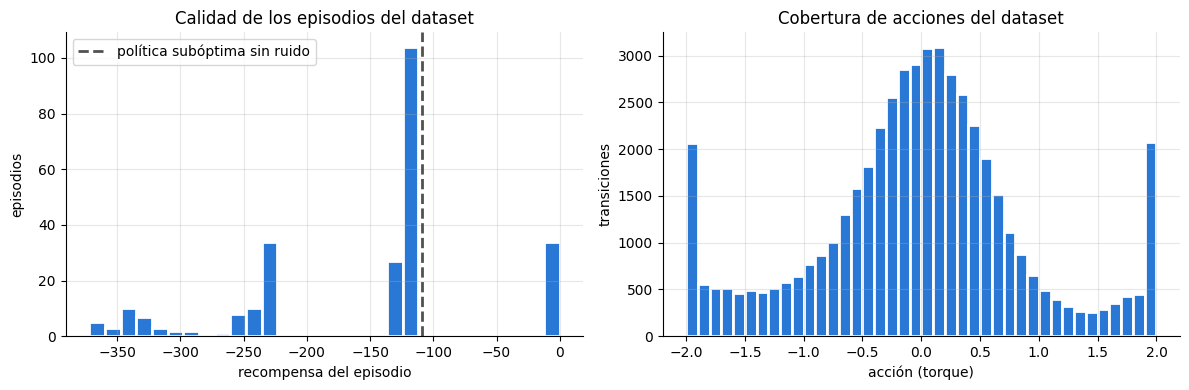

In [ ]:
def collect_dataset(agent, n=50_000, noise_std=0.3, seed=2):
    env = gym.make(ENV_ID)
    rng = np.random.default_rng(seed)
    S, A, R, S2, D = [], [], [], [], []
    ep_returns, R_ep = [], 0.0
    s, _ = env.reset(seed=seed)
    for _ in range(n):
        a = agent.act(s, explore=False) + rng.normal(0, noise_std, ACT_DIM)
        a = np.clip(a, -MAX_ACTION, MAX_ACTION).astype(np.float32)
        s2, r, term, trunc, _ = env.step(a)
        S.append(s); A.append(a); R.append(r); S2.append(s2); D.append(float(term))
        R_ep += r
        if term or trunc:
            ep_returns.append(R_ep)
            R_ep = 0.0
            s, _ = env.reset()
        else:
            s = s2
    env.close()
    data = dict(s=np.array(S, np.float32), a=np.array(A, np.float32), r=np.array(R, np.float32)[:, None],
                s2=np.array(S2, np.float32), d=np.array(D, np.float32)[:, None])
    return data, np.array(ep_returns)

if sub_info is None:
    data, ep_returns = collect_dataset(td3_sub)
    np.savez(DATASET_PATH, **data, ep_returns=ep_returns)
    sub_info = {"greedy_return": sub_greedy, "dataset_return_mean": float(ep_returns.mean()),
                "dataset_return_std": float(ep_returns.std()), "sub_log": sub_log}
    save_json("suboptima_info.json", sub_info)
elif os.path.exists(DATASET_PATH):
    npz = np.load(DATASET_PATH)
    data = {k: npz[k] for k in ["s", "a", "r", "s2", "d"]}
    ep_returns = npz["ep_returns"]
else:
    data, ep_returns = None, None   # solo hay resumen guardado (suficiente si CQL ya está entrenado)
    print("Aviso: no está el archivo del dataset; se usan los resultados resumidos guardados.")

print(f"Política subóptima sin ruido (greedy):      {sub_info['greedy_return']:8.1f}")
print(f"Episodios del dataset (con ruido N(0,0.3)): {sub_info['dataset_return_mean']:8.1f} ± {sub_info['dataset_return_std']:.1f}")
if data is not None:
    print(f"Transiciones en el dataset: {len(data['s']):,}  ({len(ep_returns)} episodios)")
    print(f"Mejor / peor episodio del dataset:          {ep_returns.max():8.1f} / {ep_returns.min():.1f}")

if data is not None:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].hist(ep_returns, bins=30, color=COLORS["TD3"], edgecolor="white", linewidth=2)
    axs[0].axvline(sub_info["greedy_return"], color=COLORS["ref"], ls="--", label="política subóptima sin ruido")
    axs[0].set_xlabel("recompensa del episodio"); axs[0].set_ylabel("episodios")
    axs[0].set_title("Calidad de los episodios del dataset"); axs[0].legend()
    axs[1].hist(data["a"][:, 0], bins=40, color=COLORS["TD3"], edgecolor="white", linewidth=2)
    axs[1].set_xlabel("acción (torque)"); axs[1].set_ylabel("transiciones")
    axs[1].set_title("Cobertura de acciones del dataset")
    plt.tight_layout(); plt.show()

### Implementación de CQL

Construimos CQL encima de nuestro SAC (es la versión "CQL(H)" del paper de Kumar et al., 2020), con exactamente la misma arquitectura de redes. La pérdida del crítico tiene dos partes: el término TD normal de SAC y el regularizador conservador

$$\alpha_{CQL}\Big(\mathbb{E}_{s\sim\mathcal{D}}\big[\log \textstyle\sum_a \exp Q(s,a)\big] - \mathbb{E}_{(s,a)\sim\mathcal{D}}\big[Q(s,a)\big]\Big)$$

En palabras: baja el valor Q de "todas" las acciones posibles y sube el de las acciones que sí aparecen en el dataset. Como las acciones son continuas, el $\log\sum\exp$ no se puede calcular exacto, así que lo aproximamos con N_ACTIONS_CQL (por defecto 10) acciones aleatorias uniformes y otras tantas muestreadas de la política (en $s$ y en $s'$), corrigiendo cada grupo por su probabilidad (muestreo por importancia), igual que en la implementación original.

El entrenamiento son 100,000 actualizaciones sobre el dataset fijo, sin tocar el entorno. El entorno solo se usa para **evaluar** cada 5,000 actualizaciones, nunca para generar datos de entrenamiento.

In [12]:
class CQL(SAC):
    name = "CQL"

    def __init__(self, alpha_cql, n_actions=10):
        super().__init__()
        self.alpha_cql = alpha_cql
        self.n = n_actions

    def extra_critic_loss(self, s, a, s2, q1, q2):
        B, N = s.shape[0], self.n
        s_rep  = s.unsqueeze(1).expand(B, N, OBS_DIM).reshape(B * N, OBS_DIM)
        s2_rep = s2.unsqueeze(1).expand(B, N, OBS_DIM).reshape(B * N, OBS_DIM)

        # acciones de muestreo: uniformes, de la política en s y de la política en s'
        a_rand = torch.empty(B * N, ACT_DIM, device=DEVICE).uniform_(-MAX_ACTION, MAX_ACTION)
        logp_rand = ACT_DIM * np.log(1.0 / (2 * MAX_ACTION))     # densidad de la uniforme
        with torch.no_grad():
            a_pi,  logp_pi  = self.actor(s_rep)
            a_pi2, logp_pi2 = self.actor(s2_rep)

        def q_on(actions):
            q1_, q2_ = self.critic(s_rep, actions)
            return q1_.view(B, N), q2_.view(B, N)

        q1_r, q2_r = q_on(a_rand)
        q1_p, q2_p = q_on(a_pi)
        q1_n, q2_n = q_on(a_pi2)
        lp, lp2 = logp_pi.view(B, N), logp_pi2.view(B, N)

        # log-sum-exp con corrección por importancia (aprox. de log ∫ exp Q(s,a) da)
        cat1 = torch.cat([q1_r - logp_rand, q1_p - lp, q1_n - lp2], dim=1)
        cat2 = torch.cat([q2_r - logp_rand, q2_p - lp, q2_n - lp2], dim=1)
        reg1 = torch.logsumexp(cat1, dim=1).mean() - q1.mean()
        reg2 = torch.logsumexp(cat2, dim=1).mean() - q2.mean()
        return self.alpha_cql * (reg1 + reg2)

def make_offline_buffer(data):
    n = len(data["s"])
    buf = ReplayBuffer(capacity=n)
    buf.s[:], buf.a[:], buf.r[:], buf.s2[:], buf.d[:] = data["s"], data["a"], data["r"], data["s2"], data["d"]
    buf.size, buf.ptr = n, 0
    return buf

def train_offline(agent, buf, n_updates=100_000, eval_every=5_000, seed=0):
    set_seed(seed)
    log = {"step": [], "eval_return": [], "q_mean": []}
    t0 = time.time()
    for t in range(1, n_updates + 1):
        agent.update(buf)
        if t % eval_every == 0:
            log["step"].append(t)
            log["eval_return"].append(evaluate(lambda o: agent.act(o, explore=False)))
            log["q_mean"].append(agent.q_estimate(FIXED_S))
            print(f"[CQL a={agent.alpha_cql}] update {t:>6} | eval {log['eval_return'][-1]:8.1f} | "
                  f"Q {log['q_mean'][-1]:8.1f} | {time.time() - t0:5.0f}s")
    return log

In [ ]:
ALPHAS_CQL = [0.5, 1.0, 5.0]
N_UPDATES_CQL = 100_000
N_ACTIONS_CQL = 10
offline_buf = make_offline_buffer(data) if data is not None else None

cql_logs = {}
for a_cql in ALPHAS_CQL:
    fname = f"cql_alpha_{a_cql}.json"
    log = load_json(fname)
    if log is None:
        assert offline_buf is not None, "Falta el dataset para entrenar CQL"
        agent = CQL(alpha_cql=a_cql, n_actions=N_ACTIONS_CQL)
        log = train_offline(agent, offline_buf, n_updates=N_UPDATES_CQL)
        log["final_eval"] = evaluate(lambda o: agent.act(o, explore=False), episodes=10, seed=50_000)
        save_json(fname, log)
    else:
        print(f"CQL alpha={a_cql}: resultados cargados de disco")
    cql_logs[a_cql] = log

[CQL a=0.5] update   5000 | eval  -1275.1 | Q    -91.5 |    83s
[CQL a=0.5] update  10000 | eval  -1301.8 | Q    -92.7 |   168s
[CQL a=0.5] update  15000 | eval   -254.7 | Q    -87.3 |   250s
[CQL a=0.5] update  20000 | eval   -749.1 | Q   -114.4 |   333s
[CQL a=0.5] update  25000 | eval   -121.3 | Q   -119.8 |   417s
[CQL a=0.5] update  30000 | eval   -120.5 | Q   -120.6 |   502s
[CQL a=0.5] update  35000 | eval   -120.5 | Q   -121.6 |   587s
[CQL a=0.5] update  40000 | eval   -120.8 | Q   -120.6 |   670s
[CQL a=0.5] update  45000 | eval   -120.6 | Q   -121.2 |   753s
[CQL a=0.5] update  50000 | eval   -120.9 | Q   -122.1 |   836s
[CQL a=0.5] update  55000 | eval   -121.1 | Q   -122.2 |   917s
[CQL a=0.5] update  60000 | eval   -120.9 | Q   -122.9 |   997s
[CQL a=0.5] update  65000 | eval   -121.5 | Q   -121.9 |  1078s
[CQL a=0.5] update  70000 | eval   -121.3 | Q   -122.6 |  1159s
[CQL a=0.5] update  75000 | eval   -121.1 | Q   -122.9 |  1242s
[CQL a=0.5] update  80000 | eval   -121.

### Comparación: CQL vs. la política que generó el dataset

Aquí hay un detalle que importa mucho. En Pendulum la recompensa de un episodio depende bastante de dónde arranca el péndulo, así que solo se pueden comparar políticas evaluadas sobre **los mismos estados iniciales**. La política subóptima se evaluó con las semillas 10000–10009, que son las mismas que usa CQL en sus evaluaciones durante el entrenamiento. Por eso la comparación principal usa esas evaluaciones. Tomamos el promedio de las últimas 5 (las últimas 25,000 actualizaciones) para que un episodio con mala suerte no decida el resultado.

La columna de "semillas nuevas" (50000–50009) es una prueba extra con estados iniciales que CQL nunca vio en sus evaluaciones. Ahí los tres α dan prácticamente lo mismo (≈ −141), lo que dice que esos arranques son más difíciles para cualquier política, no que CQL sea peor. El dataset se promedia sobre 250 episodios con arranques aleatorios, así que es una referencia de "nivel general" del comportamiento que generó los datos.

---
# Task 2.3 — Análisis de resultados

## 2.3 (a) Curvas de aprendizaje de TD3 y SAC

In [ ]:
def moving_avg(x, w=10):
    x = np.asarray(x, dtype=float)
    return np.array([x[max(0, i - w + 1): i + 1].mean() for i in range(len(x))])

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for ax in axs:
    for name, log in [("TD3", td3_log), ("SAC", sac_log)]:
        steps = np.array(log["step"])
        ax.plot(steps, log["eval_return"], color=COLORS[name], alpha=.25, lw=1)
        ax.plot(steps, moving_avg(log["eval_return"]), color=COLORS[name], label=f"{name} (media móvil 10)")
    ax.axvline(START_STEPS, color=COLORS["ref"], ls=":", lw=1)
    ax.set_xlabel("pasos de ambiente"); ax.set_ylabel("recompensa de evaluación (10 episodios)")
axs[0].set_title("Curvas de aprendizaje en Pendulum-v1"); axs[0].legend(loc="lower right")
axs[1].set_ylim(-140, -100); axs[1].set_xlim(15_000, TOTAL_STEPS)
axs[1].set_title("Zoom a la zona de convergencia (línea tenue = evaluación cruda)")
plt.tight_layout(); plt.show()

for name, log in [("TD3", td3_log), ("SAC", sac_log)]:
    ma = moving_avg(log["eval_return"])
    hits = {th: next((s for s, m in zip(log["step"], ma) if m >= th), None) for th in [-400, -250, -200]}
    raw = next(s for s, v in zip(log["step"], log["eval_return"]) if v >= -200)
    tail = np.array(log["eval_return"][50:])
    print(f"{name}: final (últimas 10 evals) = {np.mean(log['eval_return'][-10:]):7.1f} | "
          f"mejor media móvil = {ma.max():7.1f} | primera eval cruda >= -200 en paso {raw} | " +
          " | ".join(f"MA>={th} en paso {hits[th]}" for th in hits))
    print(f"     segunda mitad del entrenamiento: std = {tail.std():.2f} | peor evaluación = {tail.min():.1f}")

**Nota: hay cosas que se corrieron en un jupyter de colab por y al descargarlo no salieron los resultados de algunas celdas

SAC converge un poco más rápido. Su evaluación cruda ya estaba en −141 a los 8,000 pasos, cuando TD3 todavía iba en −1,081, y su media móvil cruza −200 en el paso 16,000 contra 18,000 de TD3. Hay que recordar que los primeros 5,000 pasos son aleatorios en ambos, así que en la práctica SAC necesitó unos 3,000 pasos de aprendizaje real y TD3 unos 5,000.

En recompensa final quedan empatados: TD3 cierra con −109.2 y SAC con −109.6 (promedio de las últimas 10 evaluaciones). La diferencia está muy por debajo del ruido de una evaluación. Lo que sí cambia es la estabilidad. En la segunda mitad del entrenamiento TD3 casi no se mueve (desviación estándar de 0.8), mientras que SAC tiene algunos bajones esporádicos hasta −121. Eso tiene sentido, porque la política de SAC sigue cambiando mientras ajusta su temperatura.

Esto coincide solo en parte con lo que predijimos en la Task 1.1b. Ahí dijimos que SAC sería más eficiente con los datos y más robusto, y lo primero sí se ve. Lo segundo no se nota, porque al final los dos llegan al mismo techo. Creemos que la causa principal es el entorno: Pendulum tiene una sola acción, una dinámica sin sorpresas y un óptimo fácil de encontrar, así que ninguno de los dos se queda atascado y la ventaja de explorar mejor que tiene SAC no alcanza a marcar diferencia.

## 2.3 (b) Valor Q promedio durante el entrenamiento

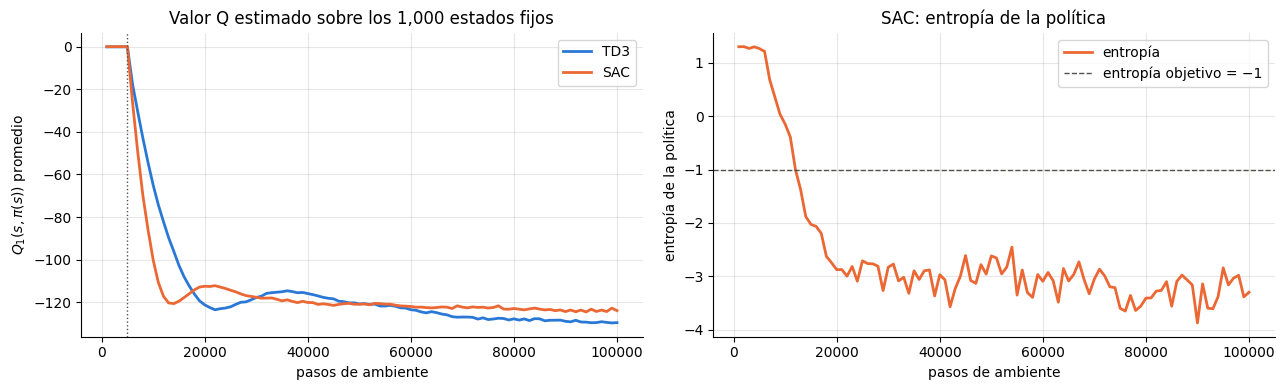

TD3: Q promedio últimas 10 evaluaciones =   -129.4 | máximo Q registrado =     -0.1
SAC: Q promedio últimas 10 evaluaciones =   -123.9 | máximo Q registrado =      0.0
SAC: alpha final = 0.0136 | entropía final = -3.299


In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for name, log in [("TD3", td3_log), ("SAC", sac_log)]:
    axs[0].plot(log["step"], log["q_mean"], color=COLORS[name], label=name)
axs[0].axvline(START_STEPS, color=COLORS["ref"], ls=":", lw=1)
axs[0].set_xlabel("pasos de ambiente"); axs[0].set_ylabel(r"$Q_1(s,\pi(s))$ promedio")
axs[0].set_title("Valor Q estimado sobre los 1,000 estados fijos"); axs[0].legend()

axs[1].plot(sac_log["step"], sac_log["entropy"], color=COLORS["SAC"], label="entropía")
axs[1].axhline(-ACT_DIM, color=COLORS["ref"], ls="--", lw=1, label="entropía objetivo = −1")
axs[1].set_xlabel("pasos de ambiente"); axs[1].set_ylabel("entropía de la política")
axs[1].set_title("SAC: entropía de la política"); axs[1].legend()
plt.tight_layout(); plt.show()

for name, log in [("TD3", td3_log), ("SAC", sac_log)]:
    print(f"{name}: Q promedio últimas 10 evaluaciones = {np.mean(log['q_mean'][-10:]):8.1f} "
          f"| máximo Q registrado = {np.max(log['q_mean']):8.1f}")
print(f"SAC: alpha final = {sac_log['alpha'][-1]:.4f} | entropía final = {sac_log['entropy'][-1]:.3f}")

hay una diferencia, aunque pequeña. Al final del entrenamiento TD3 estima un Q promedio de −129.4 y SAC de −123.9 sobre los mismos 1,000 estados, o sea que TD3 es unas 5 unidades más pesimista. La forma de las curvas también es distinta. El Q de TD3 baja casi sin parar durante todo el entrenamiento, mientras que el de SAC baja más rápido al principio (refleja que aprendió antes), rebota hacia −113 alrededor del paso 20,000 y después baja lentamente. Ninguno de los dos se dispara hacia valores positivos, que sería la señal de sobreestimación clásica. Eso es justo lo que se espera de los críticos dobles con el mínimo.

Esto encaja con lo que argumentamos en la Task 1.2b. Ahí dijimos que TD3 da estimaciones más conservadoras porque evalúa el target con acciones ruidosas y toma el mínimo de los críticos, mientras que SAC agrega un bono de entropía que sube un poco el target. Un detalle curioso es que la entropía medida sobre los estados fijos termina en −3.3, por debajo del objetivo de −1. Pasa porque $\alpha$ se ajusta con los estados que el agente visita (casi siempre el péndulo arriba y estable), mientras que el conjunto fijo incluye estados donde la política satura el torque y se vuelve casi determinista.

Para el dominio de turbinas lo más interesante es que esa conservatividad extra de TD3 no le costó nada de desempeño, ya que los dos llegan a −109. Si en el sistema real un crítico pesimista evita confiar en ángulos de pala raros sin perder energía, es una ventaja clara.

## 2.3 (c) Resultados de CQL

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
labels = ["Dataset\n(con ruido)", "Subóptima\nsin ruido"] + [f"CQL\nα={a}" for a in ALPHAS_CQL]
values = [sub_info["dataset_return_mean"], sub_info["greedy_return"]] + [cql_same_seeds(cql_logs[a]) for a in ALPHAS_CQL]
bar_colors = [COLORS["ref"], COLORS["TD3"]] + [COLORS["CQL"]] * len(ALPHAS_CQL)
bars = axs[0].bar(labels, values, color=bar_colors, width=0.6, edgecolor="white", linewidth=2)
for b, v in zip(bars, values):
    axs[0].annotate(f"{v:.0f}", (b.get_x() + b.get_width() / 2, v), xytext=(0, -4),
                    textcoords="offset points", ha="center", va="top", color=COLORS["ref"])
axs[0].set_ylabel("recompensa promedio (10 episodios)"); axs[0].set_ylim(min(values) * 1.15, 0)
axs[0].set_title("CQL vs. la política que generó el dataset\n(CQL y subóptima con las mismas semillas)")

cql_shades = ["#86b6ef", "#1baf7a", "#0d366b"]   # tres tonos distintos para los tres alphas
for (a_cql, log), c in zip(cql_logs.items(), cql_shades):
    axs[1].plot(log["step"], log["eval_return"], color=c, marker="o", ms=4, label=f"α={a_cql}")
axs[1].axhline(sub_info["dataset_return_mean"], color=COLORS["ref"], ls="--", lw=1, label="dataset")
axs[1].axhline(sub_info["greedy_return"], color=COLORS["TD3"], ls=":", lw=1.5, label="subóptima sin ruido")
axs[1].set_xlabel("actualizaciones (sin interacción)"); axs[1].set_ylabel("recompensa de evaluación")
axs[1].set_title("CQL durante el entrenamiento offline"); axs[1].legend(); axs[1].set_ylim(-400, -50)
plt.tight_layout(); plt.show()

print("Valor Q promedio final de CQL sobre los estados fijos (para ver qué tan conservador queda):")
for a_cql, log in cql_logs.items():
    print(f"  alpha={a_cql}: Q final = {log['q_mean'][-1]:8.1f} | eval (mismas semillas) = {cql_same_seeds(log):7.1f}")
print(f"  (referencia online) TD3 Q final = {td3_log['q_mean'][-1]:.1f} | SAC Q final = {sac_log['q_mean'][-1]:.1f}")

Ninguno de los tres valores supera a la política subóptima. Evaluados en las mismas semillas, CQL obtiene −116.5 con α = 0.5, −114.4 con α = 1.0 y −109.2 con α = 5.0, contra −109.1 de la política subóptima sin ruido. Lo que sí hacen los tres es superar claramente al comportamiento que aparece en el dataset, que promedia −156.4 con mucha variación (hay episodios de casi 0 y otros de −372). Es decir, CQL logra "limpiar" el ruido de los datos y recuperar la política que había detrás, pero no la mejora.

El mejor es α = 5.0, y no solo por el número final. Fue el más rápido, ya que a las 10,000 actualizaciones ya estaba en −109, y el más estable, porque en las últimas evaluaciones nunca bajó de −109.5. Con α = 0.5 y α = 1.0 la política tardó más en arrancar y sigue teniendo evaluaciones donde un episodio sale mal. Esto va en contra de lo que esperábamos en la Task 1.2c, donde recomendamos α ≈ 1.0. La razón es la forma del dataset. Todas las acciones vienen de una misma política más ruido gaussiano centrado en cero, así que la acción "promedio" en cada estado es justamente la acción de la política subóptima. Mientras más conservador es CQL, más se pega a esa acción promedio, y en este caso esa es la mejor acción disponible.

Atribuimos que nadie supere al dataset a que la política "subóptima" en realidad no era subóptima. Pendulum es tan fácil que con 20,000 pasos TD3 ya había convergido. No había margen para mejorar, el techo ya estaba alcanzado. Además, el ruido N(0, 0.3) solo agrega variaciones alrededor de una sola política, no estrategias distintas que CQL pudiera combinar para encontrar algo mejor.

## 2.3 (d) Conexión entre paradigmas

**disponibilidad de un simulador confiable**  
TD3 o SAC son buenas opciones. En nuestros experimentos los dos llegaron al óptimo en unos 16,000–18,000 pasos y además lo hicieron por su cuenta, sin depender de que alguien les diera buenos datos. Entre los dos preferiríamos SAC para entrenar, porque aprendió un poco más rápido, y TD3 si importa mucho la estabilidad de la política al final, porque fue el que menos se movió una vez convergido.  


**osto de interacción con el sistema real**  
CQL gana sin discusión. En las curvas se ve que los métodos online pasan miles de pasos con recompensas de −1,300 a −1,500 antes de aprender, el equivalente a girar el péndulo sin control. En una turbina real eso sería operar mal durante horas y arriesgar el equipo. CQL, en cambio, nunca tocó el entorno durante el entrenamiento y aun así terminó con una política tan buena como la que generó los datos. Si interactuar con la turbina es caro o peligroso, entrenar online directamente sobre ella no es opción.  


**Calidad del dataset histórico.**  
Nuestro resultado más importante es que CQL quedó igual al mejor comportamiento "consistente" de los datos, no por encima. Le ganó al promedio del dataset (−109 contra −156) porque quitó el ruido, pero no superó a la política que lo generó. Para las turbinas eso significa que CQL puede llevarnos al nivel de los buenos operadores y eliminar la inconsistencia entre turnos, pero no hay que esperar que descubra una estrategia mucho mejor que la de los mejores humanos, sobre todo con la cobertura angosta que discutimos en la Task 1.1c. También aprendimos que con datos poco diversos conviene un α alto (5.0 fue lo mejor), así que si el histórico viene de operadores muy parecidos entre sí, habría que empezar con mucho conservadurismo.

**Urgencia de despliegue.**  
Si hay que desplegar pronto y ya existen los registros, CQL es lo más rápido: con α = 5.0 llegó a su desempeño final en 10,000 actualizaciones, unos minutos de cómputo, sin esperar a recolectar experiencia nueva. TD3 o SAC requieren tener el simulador listo y validado, lo cual puede tardar meses.

**Nuestra recomendación**  
para el sistema real es combinar ambos. Primero entrenaríamos CQL con los 3 años de registros (con α alto) para tener rápido una política segura, al nivel de los mejores operadores. Después la afinaríamos con SAC en el simulador, donde equivocarse no cuesta nada, y desplegaríamos la acción media (determinista) en la turbina. Así se aprovecha que CQL es seguro y rápido de obtener, y que los métodos online son los únicos que pueden ir más allá de lo que hay en los datos.

## 2.3 (e) Investigación bibliográfica

**Referencia:** Shan Yang y Yongli Zhu (2025). Offline Reinforcement Learning for Microgrid Voltage Regulation. Presentado en ICLR 2025. arXiv:2505.09920.

El trabajo ataca la regulación de voltaje en una microrred con mucha generación solar. Cuando hay muchos paneles, el voltaje en los nodos sube y baja según la radiación y la demanda, y la forma de corregirlo es que los inversores de los paneles inyecten o absorban potencia reactiva. El agente observa las cargas, la generación solar y los voltajes de todos los nodos, y decide cuánta potencia reactiva pone cada inversor. La recompensa castiga tanto la desviación de voltaje como el uso excesivo de reactiva. Lo prueban en el sistema estándar IEEE de 33 nodos.

Comparan BCQ y CQL. El argumento para usar offline RL es el mismo que el nuestro con las turbinas: aprender por prueba y error sobre una red eléctrica real es peligroso, porque un mal ajuste puede sacar voltajes de rango y afectar equipos. Entonces se entrena solo con datos ya recolectados. BCQ restringe las acciones a algo parecido a lo que hay en los datos, mientras que CQL penaliza el valor de las acciones fuera del dataset.

Arman tres datasets de 200,000 transiciones cada uno: uno "experto" , uno "medio" y uno "pobre". CQL le gana a BCQ en los tres, y la diferencia es más clara justamente con datos de calidad media y baja. Con el dataset experto los dos funcionan bien, aunque CQL resulta un poco más estable.

En la Task 1.1c dijimos que el problema más difícil en el caso de las turbinas era la cobertura: los operadores humanos actúan en una banda estrecha y casi no hay datos de eventos extremos. El paper sí estudia la calidad del dataset de forma explícita, que es la otra condición, y muestra que CQL aguanta datos mediocres. Pero la cobertura la trata de manera mucho más amable que la realidad. Su dataset "pobre" es aleatorio, lo cual paradójicamente da una cobertura excelente de acciones, y el "medio" es el experto con ruido, que también ensancha el soporte. Ninguno de los tres se parece a nuestro caso de operadores humanos, cuyos datos son de calidad mixta y a la vez de cobertura angosta. Además todo se genera en simulación, así que no aparecen eventos raros sin representar ni el desajuste de dinámica entre turbinas "similares". Su forma de manejar el problema es solo algorítmica, y los propios autores dejan como trabajo futuro escalar a redes más grandes y complejas. Nuestra lectura es que el paper confirma que CQL es una buena elección cuando la calidad es dudosa, pero no responde qué pasa cuando lo que falta es cobertura, que para las turbinas sigue siendo el punto débil.

## Prompts
> Construye una clase cql en base a la clase SAC.  
  
  
> Dame un paper publicado entre 2023 y 2025 que aplique Offline
>RL (CQL, BCQ, IQL, o variantes) a un problema de control de sistemas energéticos, robótica industrial,
>o infraestructura física. El paper debe ser de NeurIPS, ICML, ICLR, IEEE Transactions on Power
>Systems, o similar.